## 0. 환경 & 라이브러리

In [1]:
import os, warnings, json, platform, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GroupKFold, learning_curve
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import joblib

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 ──────────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── GPU 자동 감지 ──────────────────────────────────────────────────────────
try:
    GPU_AVAILABLE = subprocess.run(['nvidia-smi'], capture_output=True).returncode == 0
except:
    GPU_AVAILABLE = False
XGB_DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'
LGB_DEVICE  = 'gpu'  if GPU_AVAILABLE else 'cpu'
print(f'✅ 라이브러리 로드 완료')
print(f'   GPU: {GPU_AVAILABLE} | XGB={XGB_DEVICE} | LGB={LGB_DEVICE}')


✅ 라이브러리 로드 완료
   GPU: True | XGB=cuda | LGB=gpu


In [2]:
# ── 컬럼 정의 ─────────────────────────────────────────────────────────────
RAW_COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP  = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
print('✅ 컬럼 정의 완료')


✅ 컬럼 정의 완료


## 1. CONFIG — 파이프라인 파라미터

In [ ]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 수동 추가
    'manual_remove_sensors': ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19'],

  # 'BASE_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
  #                   's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    # RUL Cap
    'rul_cap': 120,

    # Gaussian sigma (None=skip)
    'gaussian_sigma': 2,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'minmax',

    # ── 시계열 파생변수 ──────────────────────────────────
    'rolling_means':[5],
    'diffs':        [],
    'lags':         [],
    'rolling_stds': [],
    'emas':         [],
}

# 슬라이딩 윈도우 (DL용 — 여기선 미사용, 참조용)
WINDOW_SIZE  = 30
CONST_THR    = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k, v in CONFIG.items():
    print(f'   {k:22s}: {v}')
print(f'\n   CONST_THR={CONST_THR} | VALID_RATIO={VALID_RATIO} | RANDOM_STATE={RANDOM_STATE}')


✅ CONFIG 로드 완료
   manual_remove_sensors : ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
   rul_cap               : 120
   gaussian_sigma        : 2
   normalize             : minmax
   rolling_means         : [100]
   diffs                 : [60]
   lags                  : [70]
   rolling_stds          : [60]
   emas                  : [80]

   CONST_THR=0.01 | VALID_RATIO=0.2 | RANDOM_STATE=42


## 2. 데이터 로딩

In [4]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD001.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD003 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')


✅ FD003 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)


## 3. 파이프라인 함수 정의

In [5]:
# ============================================================
# 🔧 파이프라인 함수 (FD003 No-Clustering 전용)
# ============================================================

def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=None):
    # 1. 제거 대상: 사용자가 입력한 리스트 그대로 사용 (중복 제거 및 정렬만 수행)
    remove = sorted(list(set(manual_remove or [])))
    
    # 2. 유지 대상: 전체 21개 센서 중 위 리스트에 없는 것만 남김
    useful = [s for s in sensor_cols if s not in remove]
    
    # s_1, s_2 순서대로 예쁘게 정렬
    useful = sorted(useful, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    
    return useful, remove


def add_piecewise_rul(df, cap):
    """엔진별 RUL 계산 후 cap 적용"""
    df  = df.copy()
    mc  = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df  = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_by_unit(df, features, sigma):
    """엔진 단위 가우시안 스무딩"""
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    def _smooth(s):
        return gaussian_filter1d(s.values.astype(np.float32), sigma=sigma, mode='nearest') if len(s) > 1 else s.values
    for col in features:
        df[col] = df.groupby('unit_nr')[col].transform(_smooth)
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진 단위 random split"""
    units = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio, random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


def normalize_global(sub, val, test, features, method):
    """전체 정규화 (sub-train 기준 fit) — FD003은 단일 운전조건이므로 전체 적용"""
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scaler    = ScalerCls()
    sub  = sub.copy();  val  = val.copy();  test = test.copy()
    sub[features]  = scaler.fit_transform(sub[features])
    val[features]  = scaler.transform(val[features])
    test[features] = scaler.transform(test[features])
    return sub, val, test, scaler


def add_temporal_features(df, sensor_cols, lags, diffs, rolls, roll_stds, emas):
    """엔진 단위 시계열 파생변수 생성"""
    df = df.copy().sort_values(['unit_nr', 'time_cycles'])
    for s in sensor_cols:
        grp = df.groupby('unit_nr')[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}']     = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}']      = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}']      = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}']   = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}']    = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)


def run_pipeline(train_raw, test_raw, cfg):
    """FD003 전처리 파이프라인 (No-Clustering)"""
    # 1. 센서 필터링
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개  {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1  = train_raw[keep].copy()
    te1  = test_raw[keep].copy()

    # 2. Piecewise RUL
    tr2 = add_piecewise_rul(tr1, cap=cfg['rul_cap'])
    te2 = te1.copy()
    print(f'[2] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # 3. Gaussian Smoothing
    if cfg.get('gaussian_sigma') and cfg['gaussian_sigma'] > 0:
        tr3 = apply_gaussian_by_unit(tr2, useful, sigma=cfg['gaussian_sigma'])
        te3 = apply_gaussian_by_unit(te2, useful, sigma=cfg['gaussian_sigma'])
        print(f'[3] Gaussian σ={cfg["gaussian_sigma"]} 적용')
    else:
        tr3, te3 = tr2, te2
        print('[3] Gaussian skip')

    # 4. Split
    sub4, val4, sub_units, val_units = split_by_unit(tr3, VALID_RATIO, RANDOM_STATE)
    test4 = te3.copy()
    print(f'[4] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # 5. 정규화 (전체 MinMax — FD003은 단일 운전조건)
    sub5, val5, test5, scaler = normalize_global(sub4, val4, test4, useful, cfg['normalize'])
    print(f'[5] 전체 정규화 완료 ({cfg["normalize"]})')

    # 6. 시계열 파생변수
    sub6  = add_temporal_features(sub5,  useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    val6  = add_temporal_features(val5,  useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    test6 = add_temporal_features(test5, useful, cfg['lags'], cfg['diffs'],
                                   cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])

    EXCLUDE    = set(ID_COLS + OP_COLS + ['RUL', 'RUL_raw'])
    ml_features = [c for c in sub6.columns if c not in EXCLUDE]
    print(f'[6] 파생변수 생성 완료 (ML features={len(ml_features)}개)')

    return {
        'subtrain_ml': sub6, 'valid_ml': val6, 'test_ml': test6,
        'ml_features': ml_features, 'scaler': scaler,
    }

print('✅ 파이프라인 함수 정의 완료')


✅ 파이프라인 함수 정의 완료


## 4. 파이프라인 실행

In [6]:
data        = run_pipeline(train_raw, test_raw, CONFIG)

train_ml    = data['subtrain_ml'].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
valid_ml    = data['valid_ml'   ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
test_ml     = data['test_ml'    ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
ML_FEATURES = data['ml_features']
scaler_obj  = data['scaler']

# Test 평가: 엔진별 마지막 사이클만
test_last   = test_ml.groupby('unit_nr').last().reset_index()
X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val,   y_val   = valid_ml[ML_FEATURES], valid_ml['RUL']
X_test           = test_last[ML_FEATURES]
y_test           = rul_df['RUL'].values

print(f'\n[실행 결과]')
print(f'  Sub-train : {train_ml.shape}')
print(f'  Validation: {valid_ml.shape}')
print(f'  Test      : {test_ml.shape}')
print(f'  ML 피처 수: {len(ML_FEATURES)}개')
print(f'  주요 피처 : {ML_FEATURES[:8]}...')


[1] 센서 필터링: 유지 15개 / 제거 6개  ['s_1', 's_10', 's_16', 's_18', 's_19', 's_5']
[2] Piecewise RUL 적용 (cap=120)
[3] Gaussian σ=2 적용
[4] 데이터 분할: sub=80대 / val=20대
[5] 전체 정규화 완료 (minmax)
[6] 파생변수 생성 완료 (ML features=90개)

[실행 결과]
  Sub-train : (16561, 97)
  Validation: (4070, 97)
  Test      : (13096, 95)
  ML 피처 수: 90개
  주요 피처 : ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11']...


## 5. 평가 유틸 & 시각화 함수

In [7]:
# ── NASA Score ────────────────────────────────────────────────────────────
def calculate_nasa_score(y_true, y_pred):
    d     = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

def get_metrics(y_true, y_pred, cap=CONFIG['rul_cap']):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, cap)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE'       : float(mean_absolute_error(y_true, pred)),
        'R2'        : float(r2_score(y_true, pred)),
        'NASA_Score': calculate_nasa_score(y_true, pred),
    }

# ── 통합 시각화 함수 (2×3 — 6 plots) ───────────────────────────────────────
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False, eval_results=None):
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    res = {
        'Train': get_metrics(y_train, pred_train),
        'Valid': get_metrics(y_val,   pred_val),
        'Test' : get_metrics(y_test,  pred_test),
    }

    print(f"\n{'='*55}\n 🏆 {model_name} 평가 결과\n{'='*55}")
    for split, m in res.items():
        print(f" [{split:5s}] RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | "
              f"R2={m['R2']:.4f} | NASA={m['NASA_Score']:.1f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'{model_name} — 전체 평가 (FD003)', fontsize=14, fontweight='bold')
    plt.subplots_adjust(hspace=0.35)

    # 1. Learning / Loss Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_sc, v_sc = learning_curve(
            model, X_train, y_train, cv=3, scoring='neg_root_mean_squared_error',
            train_sizes=np.linspace(0.2, 1.0, 5))
        ax1.plot(sizes, -np.mean(t_sc, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_sc, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('① Learning / Loss Curve'); ax1.legend(); ax1.grid(True)

    # 2. Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange', s=8)
    axes[0, 1].axhline(0, color='red', ls='--')
    axes[0, 1].set_title('② Residual Plot (Validation)')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residual')

    # 3. Feature Importance / Coefficient Top-15
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    idx = np.argsort(imp)[-15:]
    ax3.barh(range(15), imp[idx], color='teal')
    ax3.set_yticks(range(15))
    ax3.set_yticklabels(np.array(ML_FEATURES)[idx], fontsize=8)
    ax3.set_title('③ Top-15 Feature Importance')

    # 4. Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val,   label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val,label='Pred',   ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('④ RUL 분포 비교 (Validation)'); axes[1, 0].legend()

    # 5. Feature Weight Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('⑤ Feature Weight Histogram')

    # 6. Test — Actual vs Predicted Line
    ax6 = axes[1, 2]
    ax6.plot(y_test,    label='Actual RUL',    color='black', lw=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', ls='--', alpha=0.8)
    ax6.set_title('⑥ Test: Actual vs Predicted')
    ax6.set_xlabel('Engine Index'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)

    plt.tight_layout()
    plt.show()
    return res

print('✅ 평가 & 시각화 함수 정의 완료')


✅ 평가 & 시각화 함수 정의 완료


## 6. 일반 실험 (기본 하이퍼파라미터)


 🏆 Ridge 평가 결과
 [Train] RMSE=12.0275 | MAE=8.8702 | R2=0.9089 | NASA=35018.2
 [Valid] RMSE=11.4731 | MAE=8.5083 | R2=0.9174 | NASA=7716.6
 [Test ] RMSE=16.6217 | MAE=13.0629 | R2=0.8400 | NASA=385.3


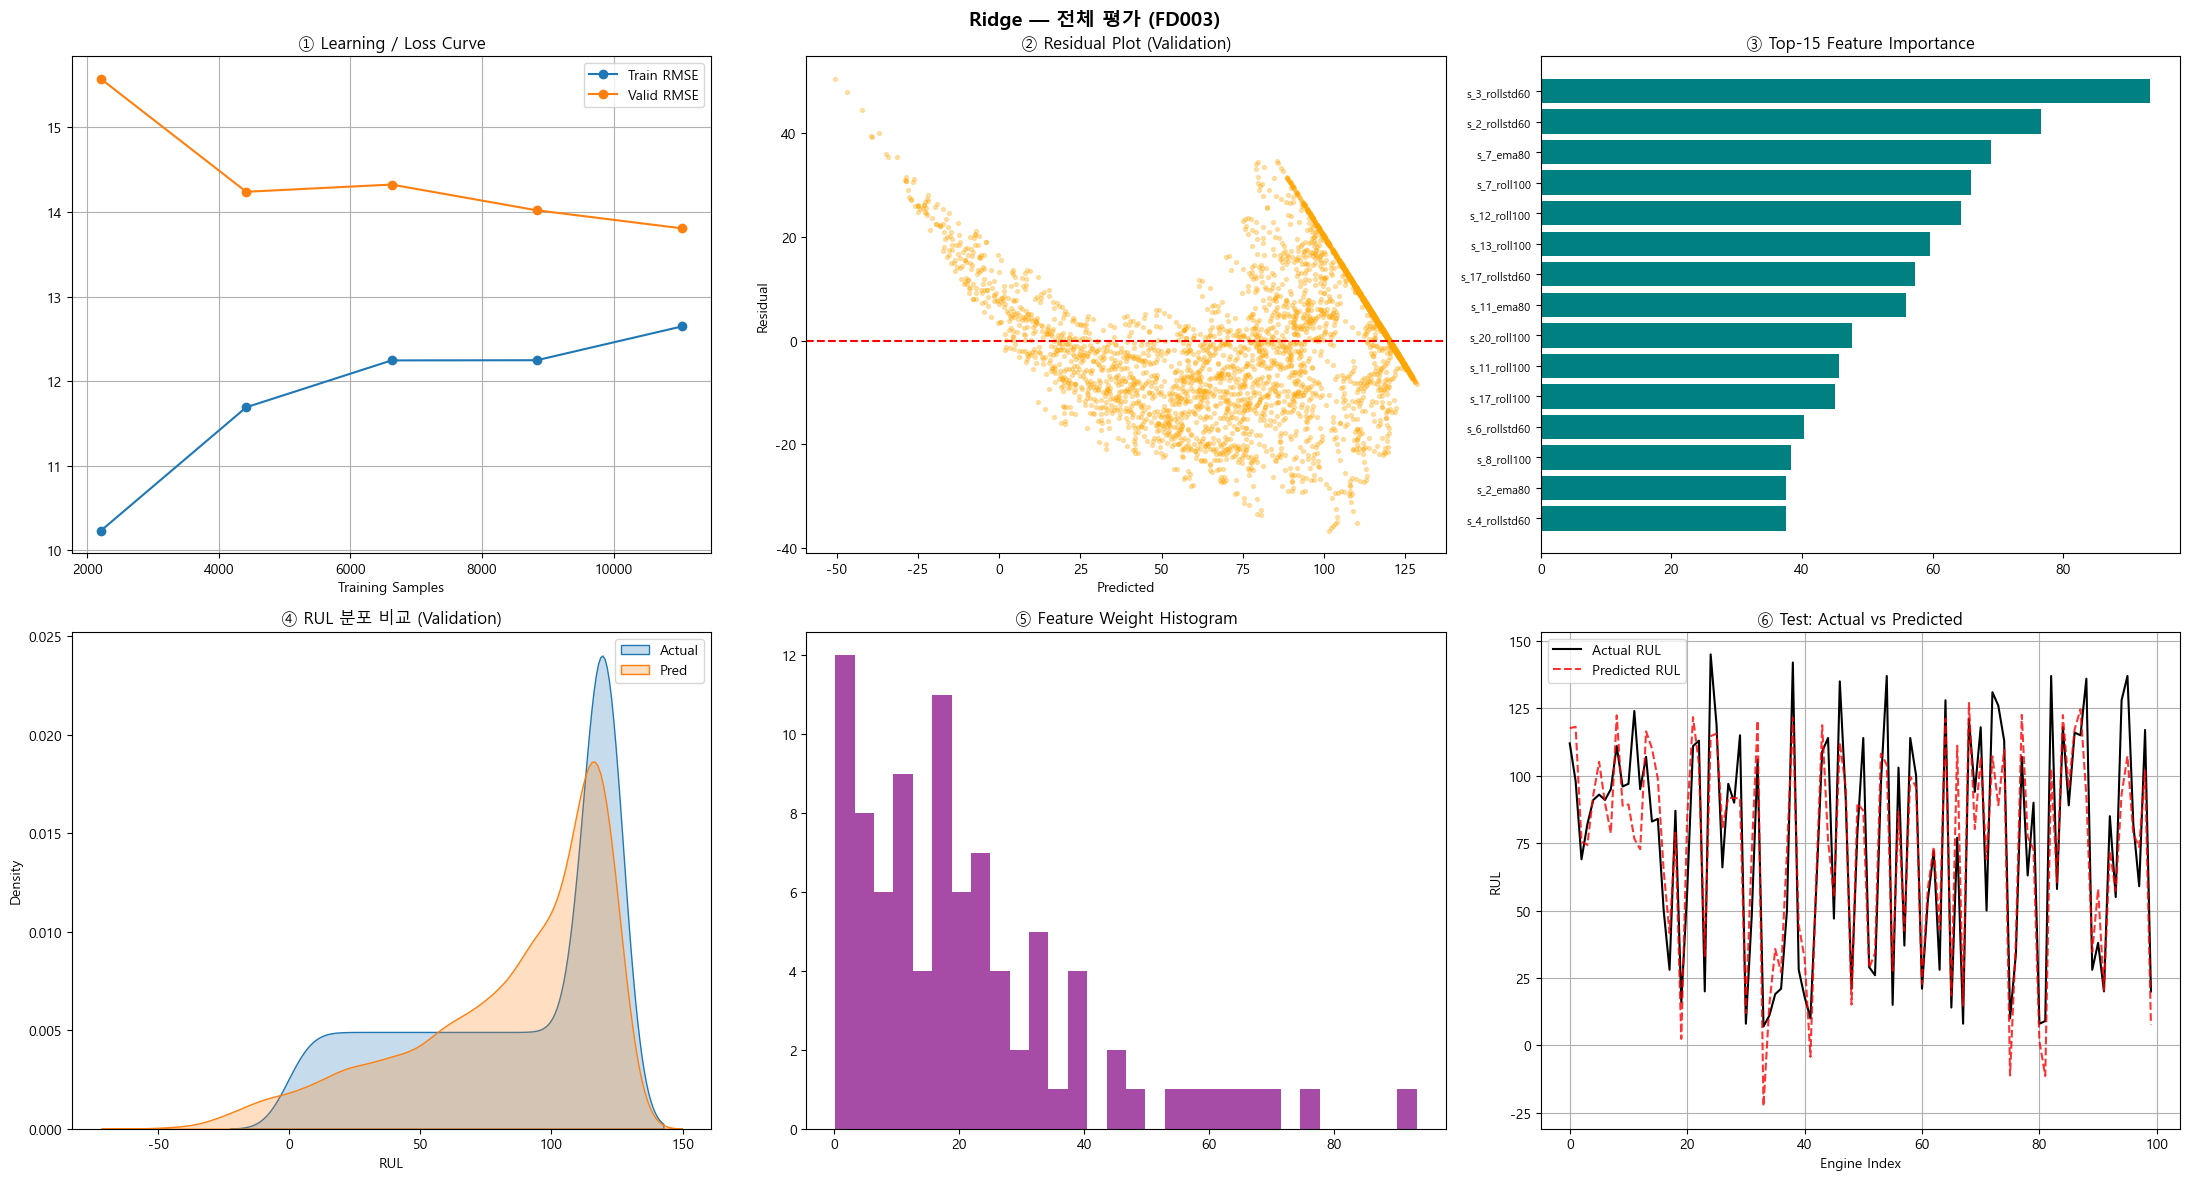

{'Train': {'RMSE': 12.027525449786895,
  'MAE': 8.870187531175409,
  'R2': 0.908868335068494,
  'NASA_Score': 35018.175336700624},
 'Valid': {'RMSE': 11.473093100516971,
  'MAE': 8.508299540219145,
  'R2': 0.9173785355941575,
  'NASA_Score': 7716.637669478852},
 'Test': {'RMSE': 16.621749352894653,
  'MAE': 13.062915088663999,
  'R2': 0.840009603764839,
  'NASA_Score': 385.2569949842719}}

In [9]:
# ── Ridge ─────────────────────────────────────────────────────────────────
ridge_params = {'alpha': 1.0, 'solver': 'auto', 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_ridge  = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)
evaluate_full_pipeline(model_ridge, 'Ridge')



 🏆 Lasso 평가 결과
 [Train] RMSE=13.1477 | MAE=9.9355 | R2=0.8911 | NASA=41419.6
 [Valid] RMSE=12.0606 | MAE=9.2337 | R2=0.9087 | NASA=8302.8
 [Test ] RMSE=16.6637 | MAE=13.2084 | R2=0.8392 | NASA=372.3


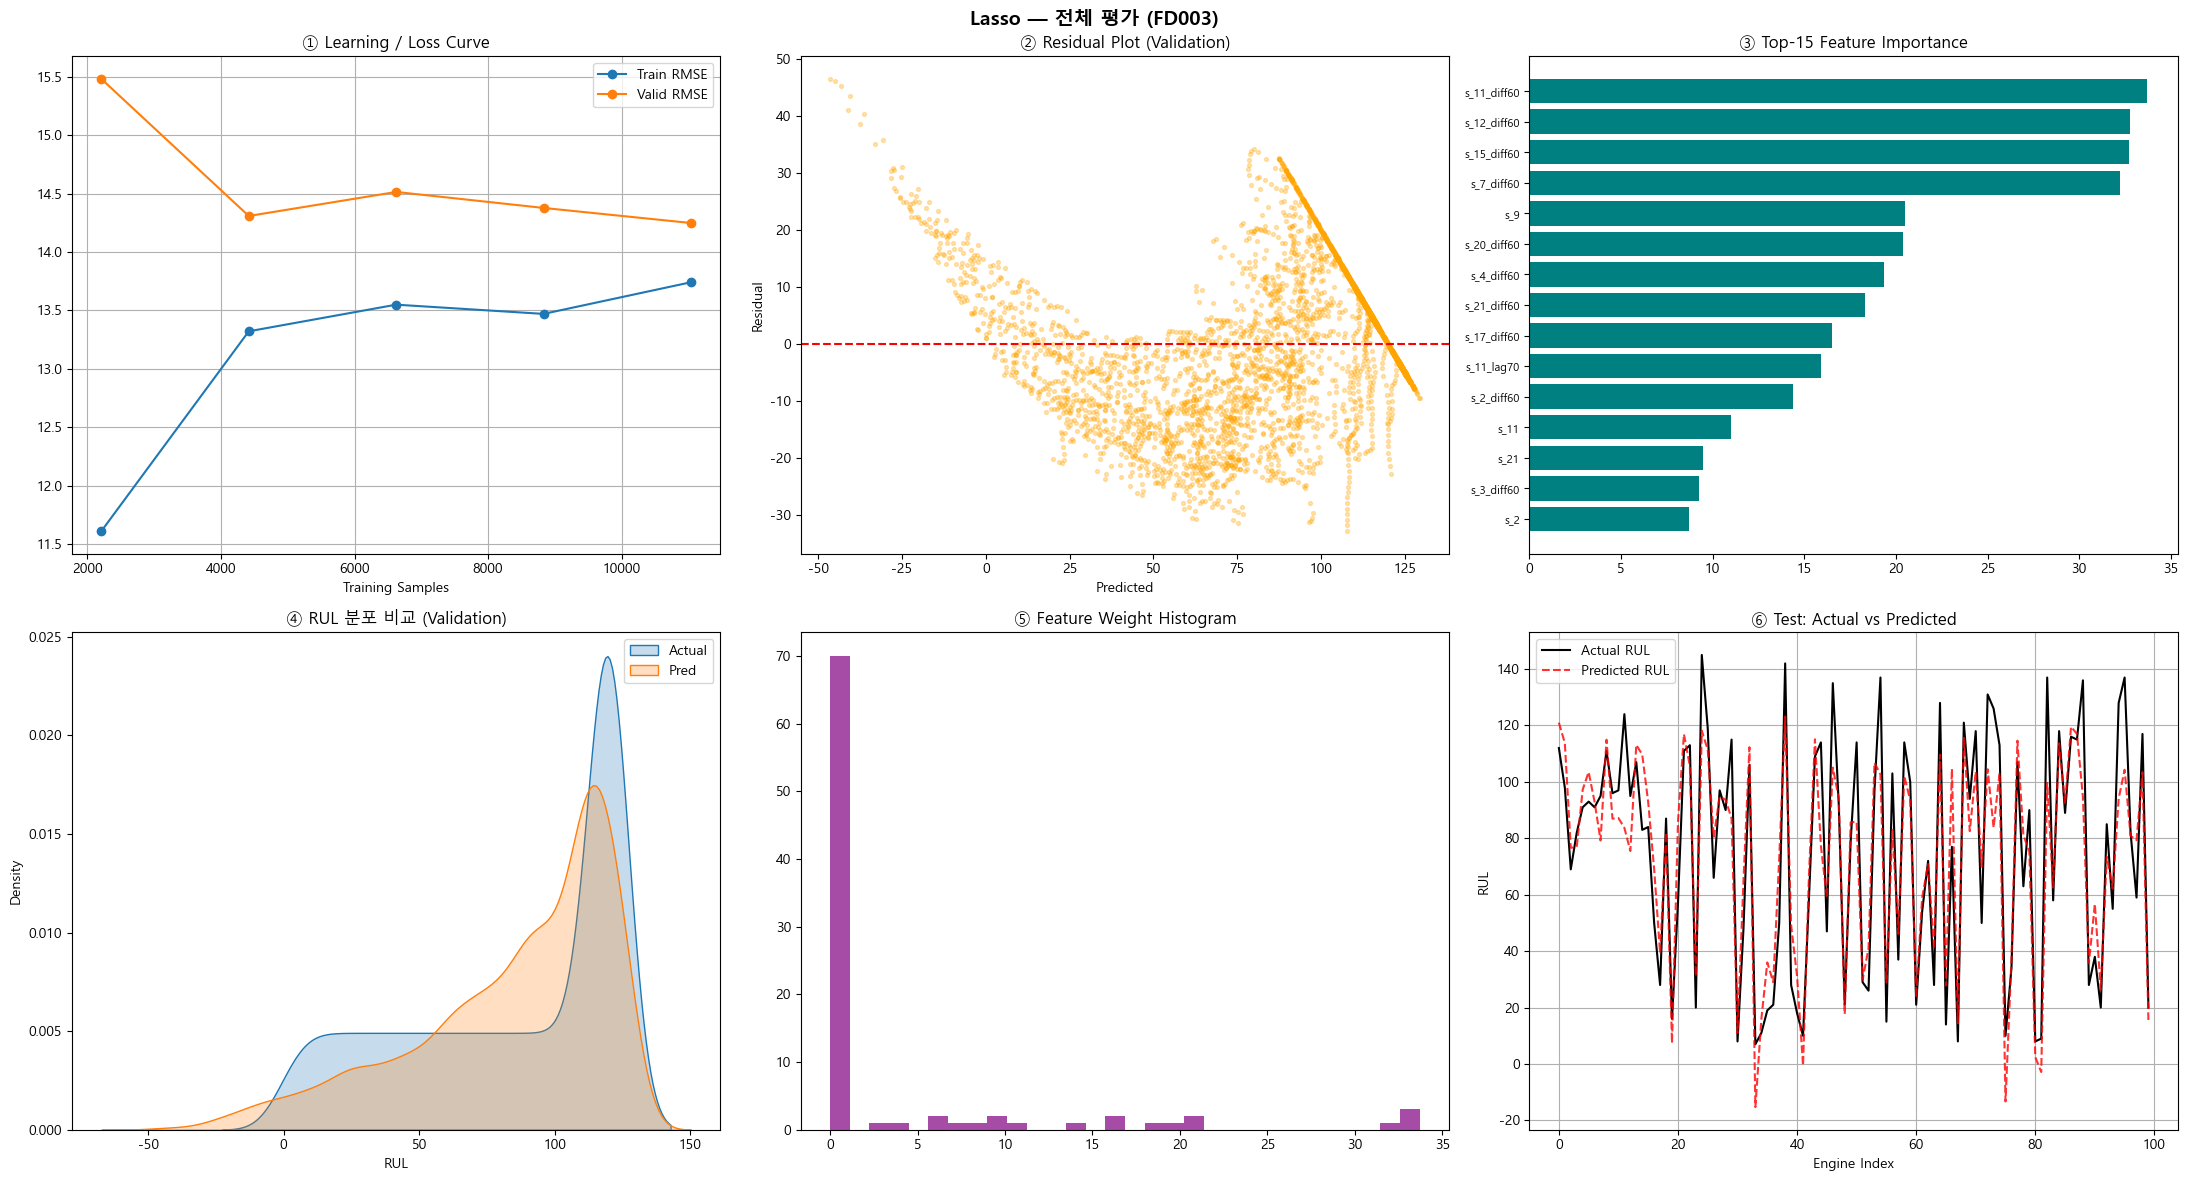

{'Train': {'RMSE': 13.147749481294987,
  'MAE': 9.935471854173986,
  'R2': 0.8911020820519904,
  'NASA_Score': 41419.60103966287},
 'Valid': {'RMSE': 12.060643243985824,
  'MAE': 9.233747940477006,
  'R2': 0.9086995758693117,
  'NASA_Score': 8302.796036208829},
 'Test': {'RMSE': 16.663733755913036,
  'MAE': 13.208417475692418,
  'R2': 0.8392003526566478,
  'NASA_Score': 372.31777040375323}}

In [10]:
# ── Lasso ─────────────────────────────────────────────────────────────────
lasso_params = {'alpha': 0.1, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_lasso  = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)
evaluate_full_pipeline(model_lasso, 'Lasso')



 🏆 ElasticNet 평가 결과
 [Train] RMSE=15.4457 | MAE=12.1069 | R2=0.8497 | NASA=53946.6
 [Valid] RMSE=14.1643 | MAE=11.2518 | R2=0.8741 | NASA=10714.0
 [Test ] RMSE=19.0583 | MAE=15.3612 | R2=0.7897 | NASA=514.6


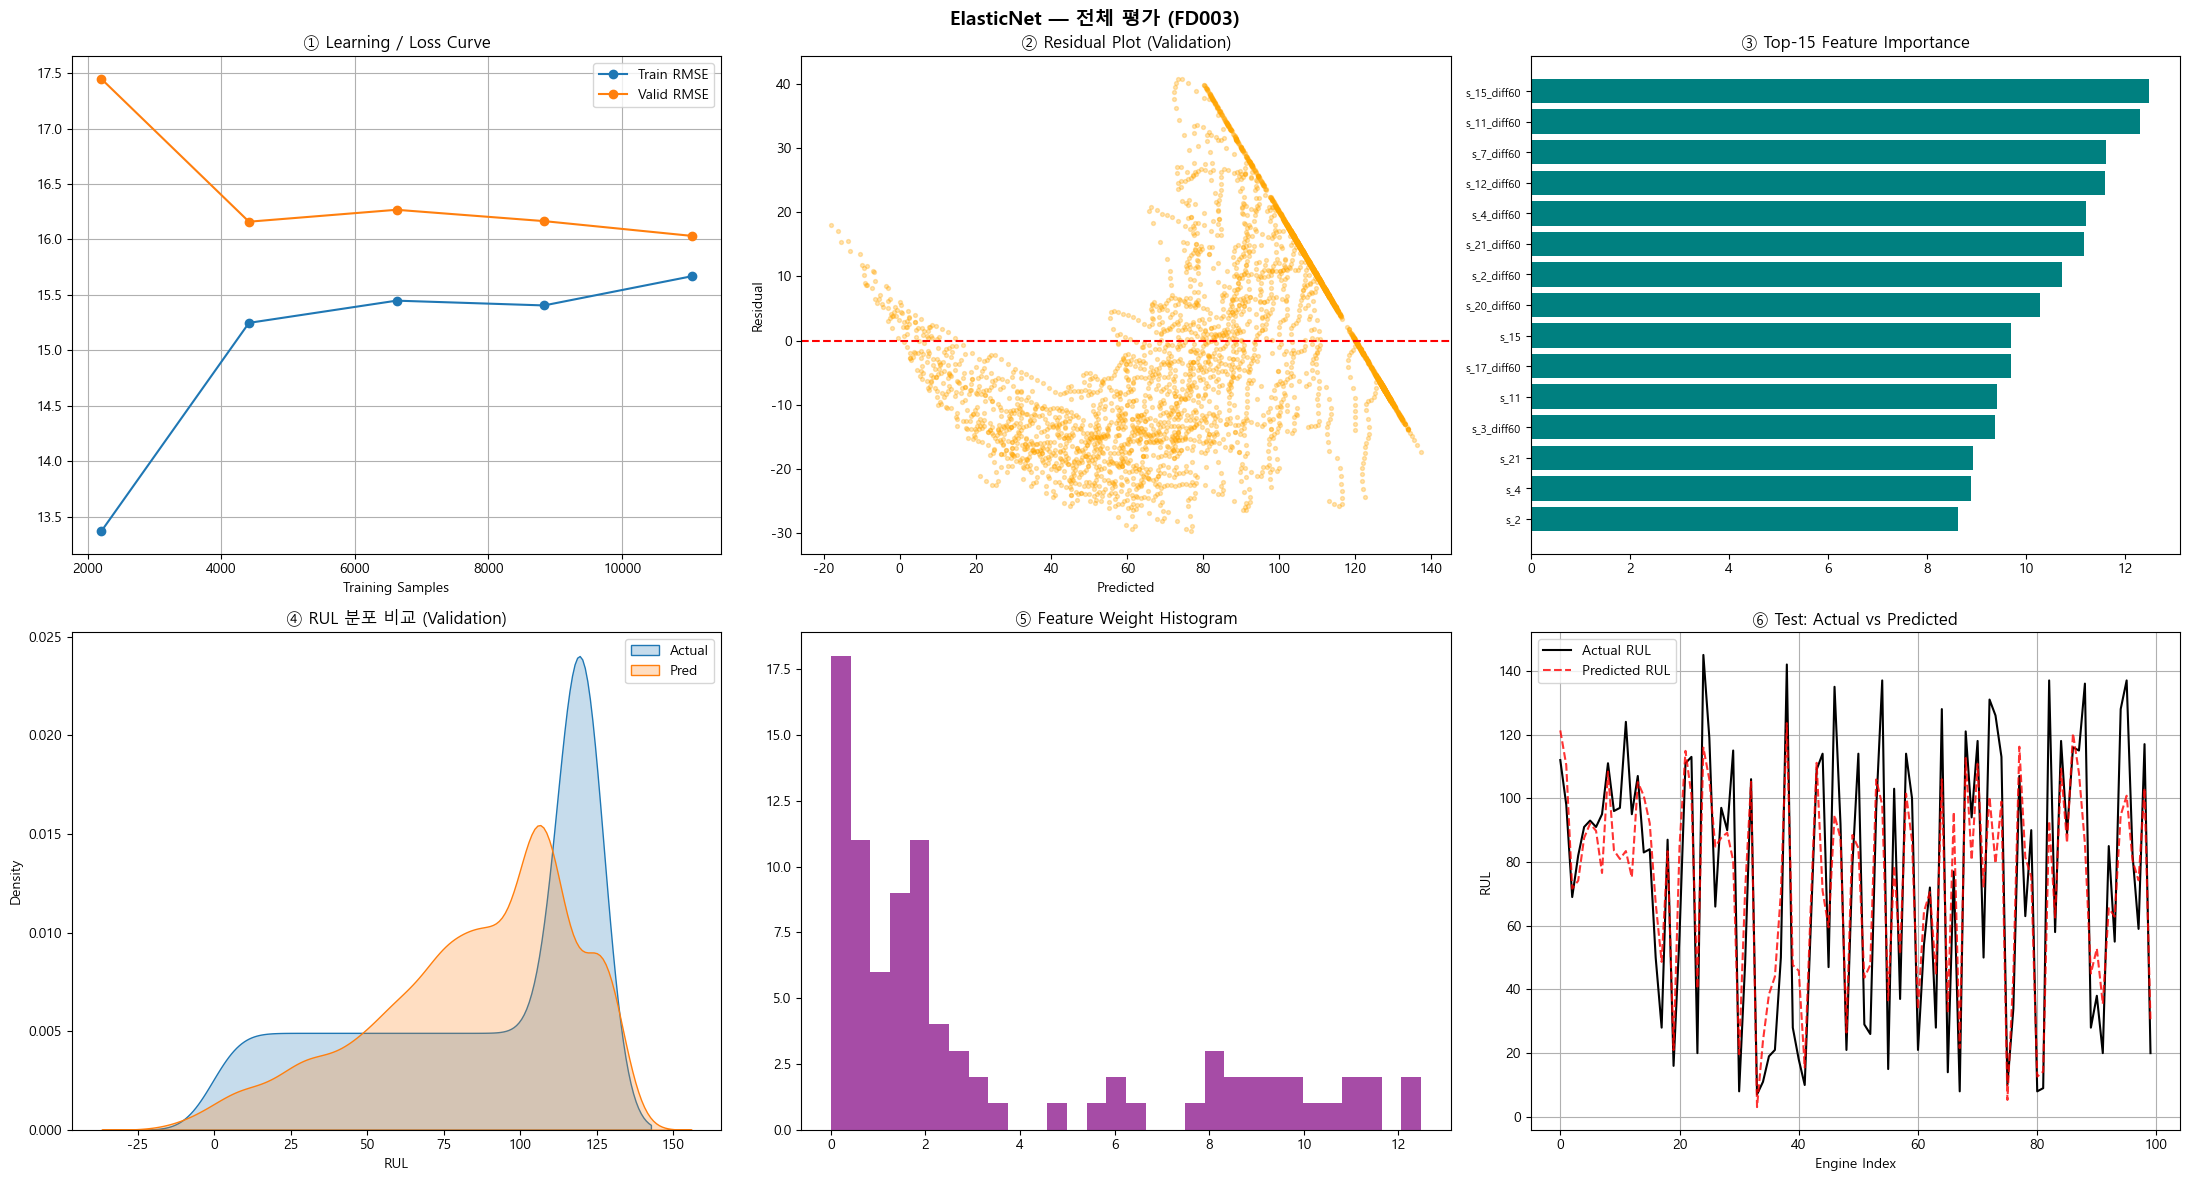

{'Train': {'RMSE': 15.445745715863845,
  'MAE': 12.10694627921156,
  'R2': 0.849708472956727,
  'NASA_Score': 53946.6215525064},
 'Valid': {'RMSE': 14.164325289144188,
  'MAE': 11.251829013671664,
  'R2': 0.8740716141464009,
  'NASA_Score': 10714.049501704201},
 'Test': {'RMSE': 19.05834166073069,
  'MAE': 15.361204832700352,
  'R2': 0.7896654229959558,
  'NASA_Score': 514.5770589904475}}

In [11]:
# ── ElasticNet ────────────────────────────────────────────────────────────
elastic_params = {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_elastic  = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)
evaluate_full_pipeline(model_elastic, 'ElasticNet')



 🏆 RandomForest 평가 결과
 [Train] RMSE=4.6931 | MAE=3.0707 | R2=0.9861 | NASA=7104.3
 [Valid] RMSE=8.7063 | MAE=5.9220 | R2=0.9524 | NASA=5369.4
 [Test ] RMSE=13.4006 | MAE=10.1350 | R2=0.8960 | NASA=219.3


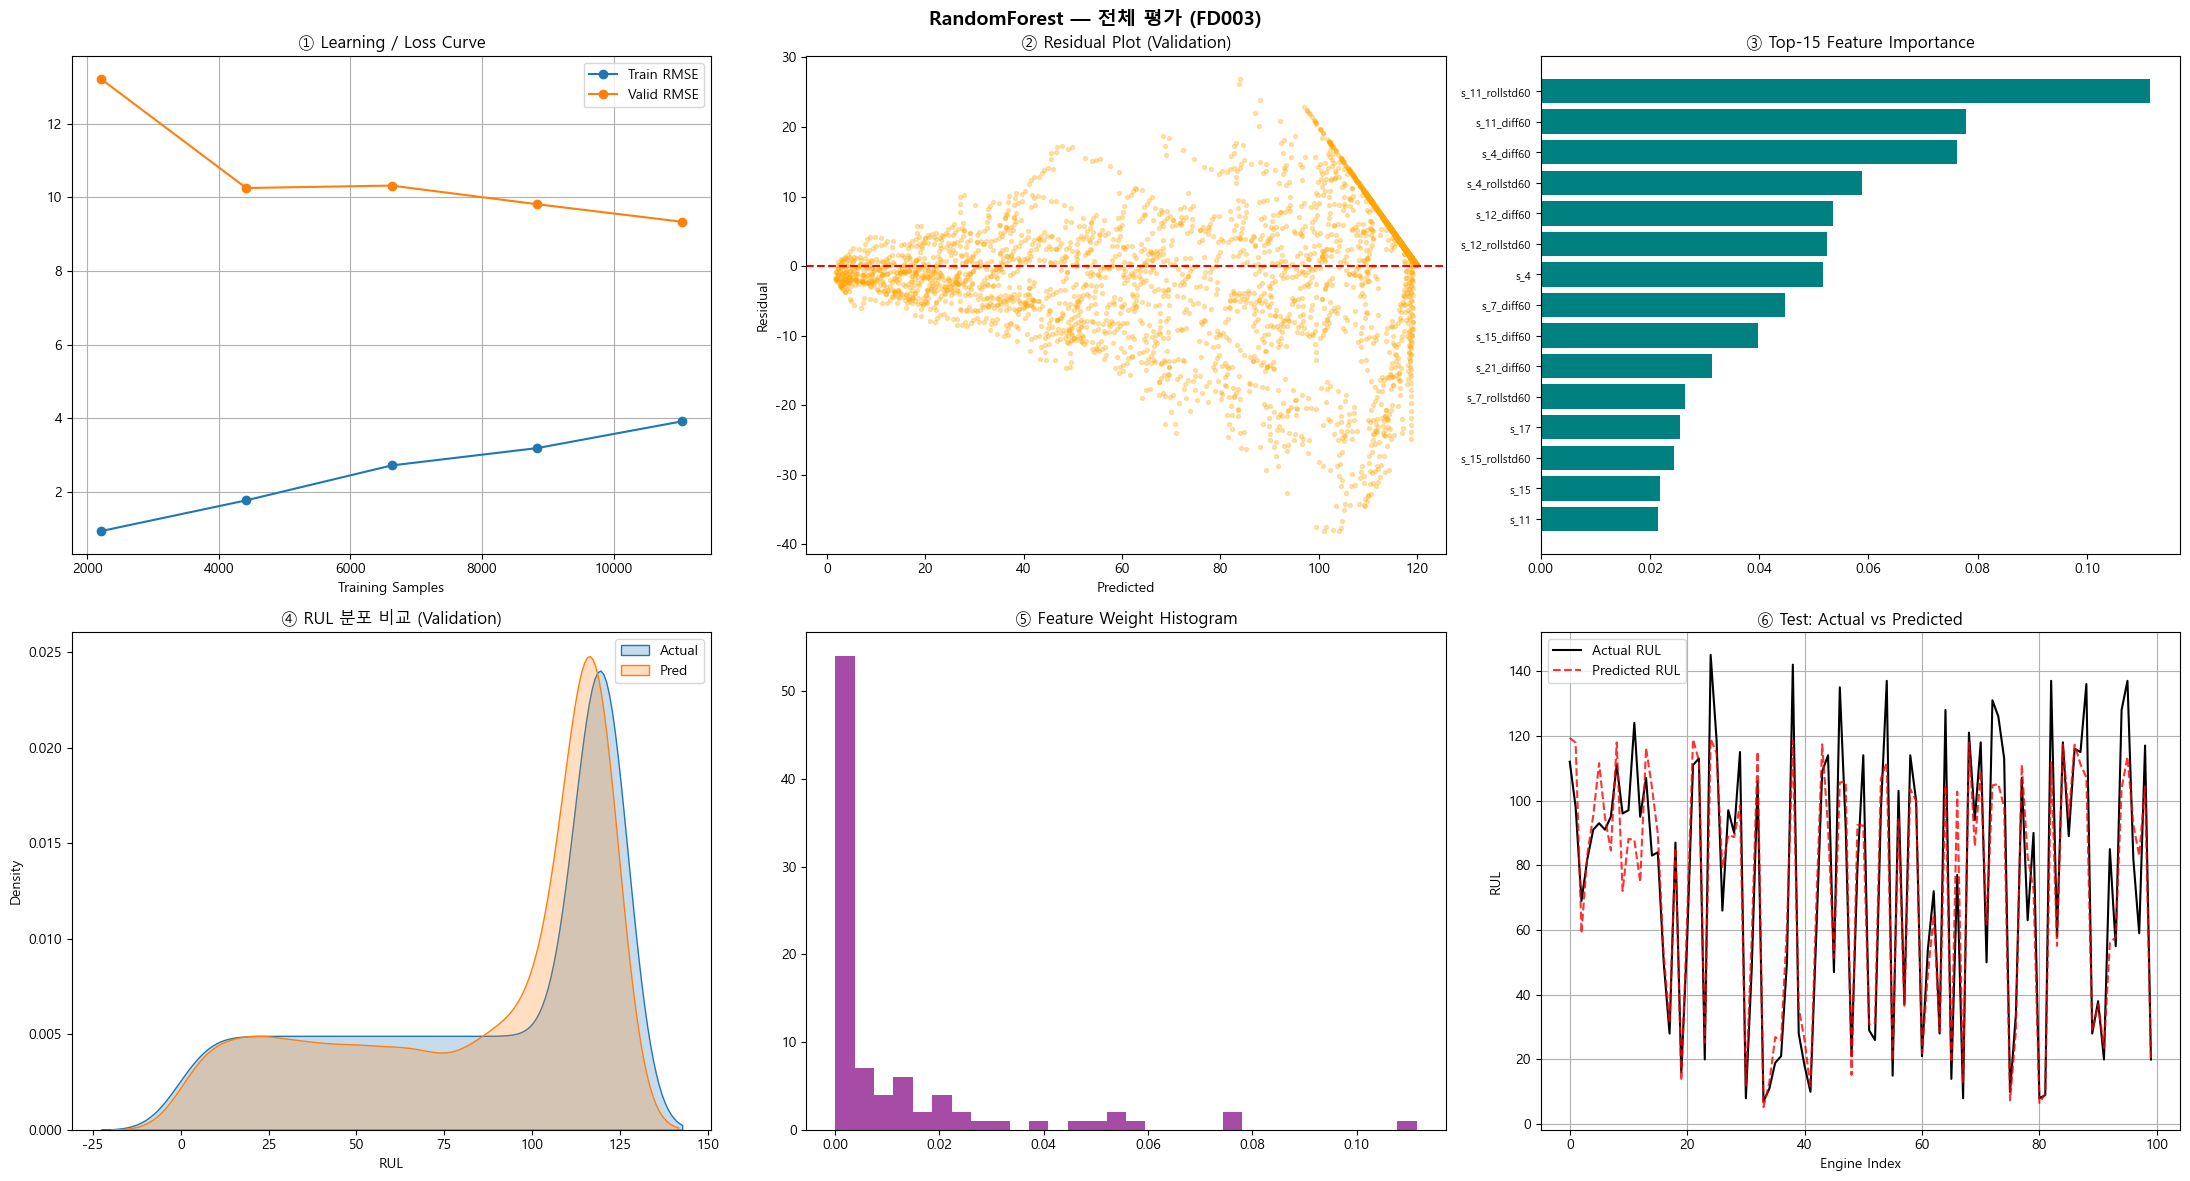

{'Train': {'RMSE': 4.693141135566205,
  'MAE': 3.070702894926077,
  'R2': 0.9861246494098826,
  'NASA_Score': 7104.29465191648},
 'Valid': {'RMSE': 8.706254947511052,
  'MAE': 5.9219570019158745,
  'R2': 0.952423267296962,
  'NASA_Score': 5369.440307030945},
 'Test': {'RMSE': 13.400640127562468,
  'MAE': 10.135040331575143,
  'R2': 0.8960100080350957,
  'NASA_Score': 219.27085818754543}}

In [12]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_params = {
    'n_estimators': 200, 'max_depth': 10,
    'min_samples_split': 5, 'min_samples_leaf': 2,
    'max_features': 'sqrt', 'n_jobs': -1, 'random_state': RANDOM_STATE
}
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)
evaluate_full_pipeline(model_rf, 'RandomForest', is_tree=True)



 🏆 LightGBM (gpu) 평가 결과
 [Train] RMSE=4.6501 | MAE=3.1317 | R2=0.9864 | NASA=7045.5
 [Valid] RMSE=9.1054 | MAE=6.0316 | R2=0.9480 | NASA=5920.2
 [Test ] RMSE=13.0711 | MAE=9.7455 | R2=0.9011 | NASA=211.3


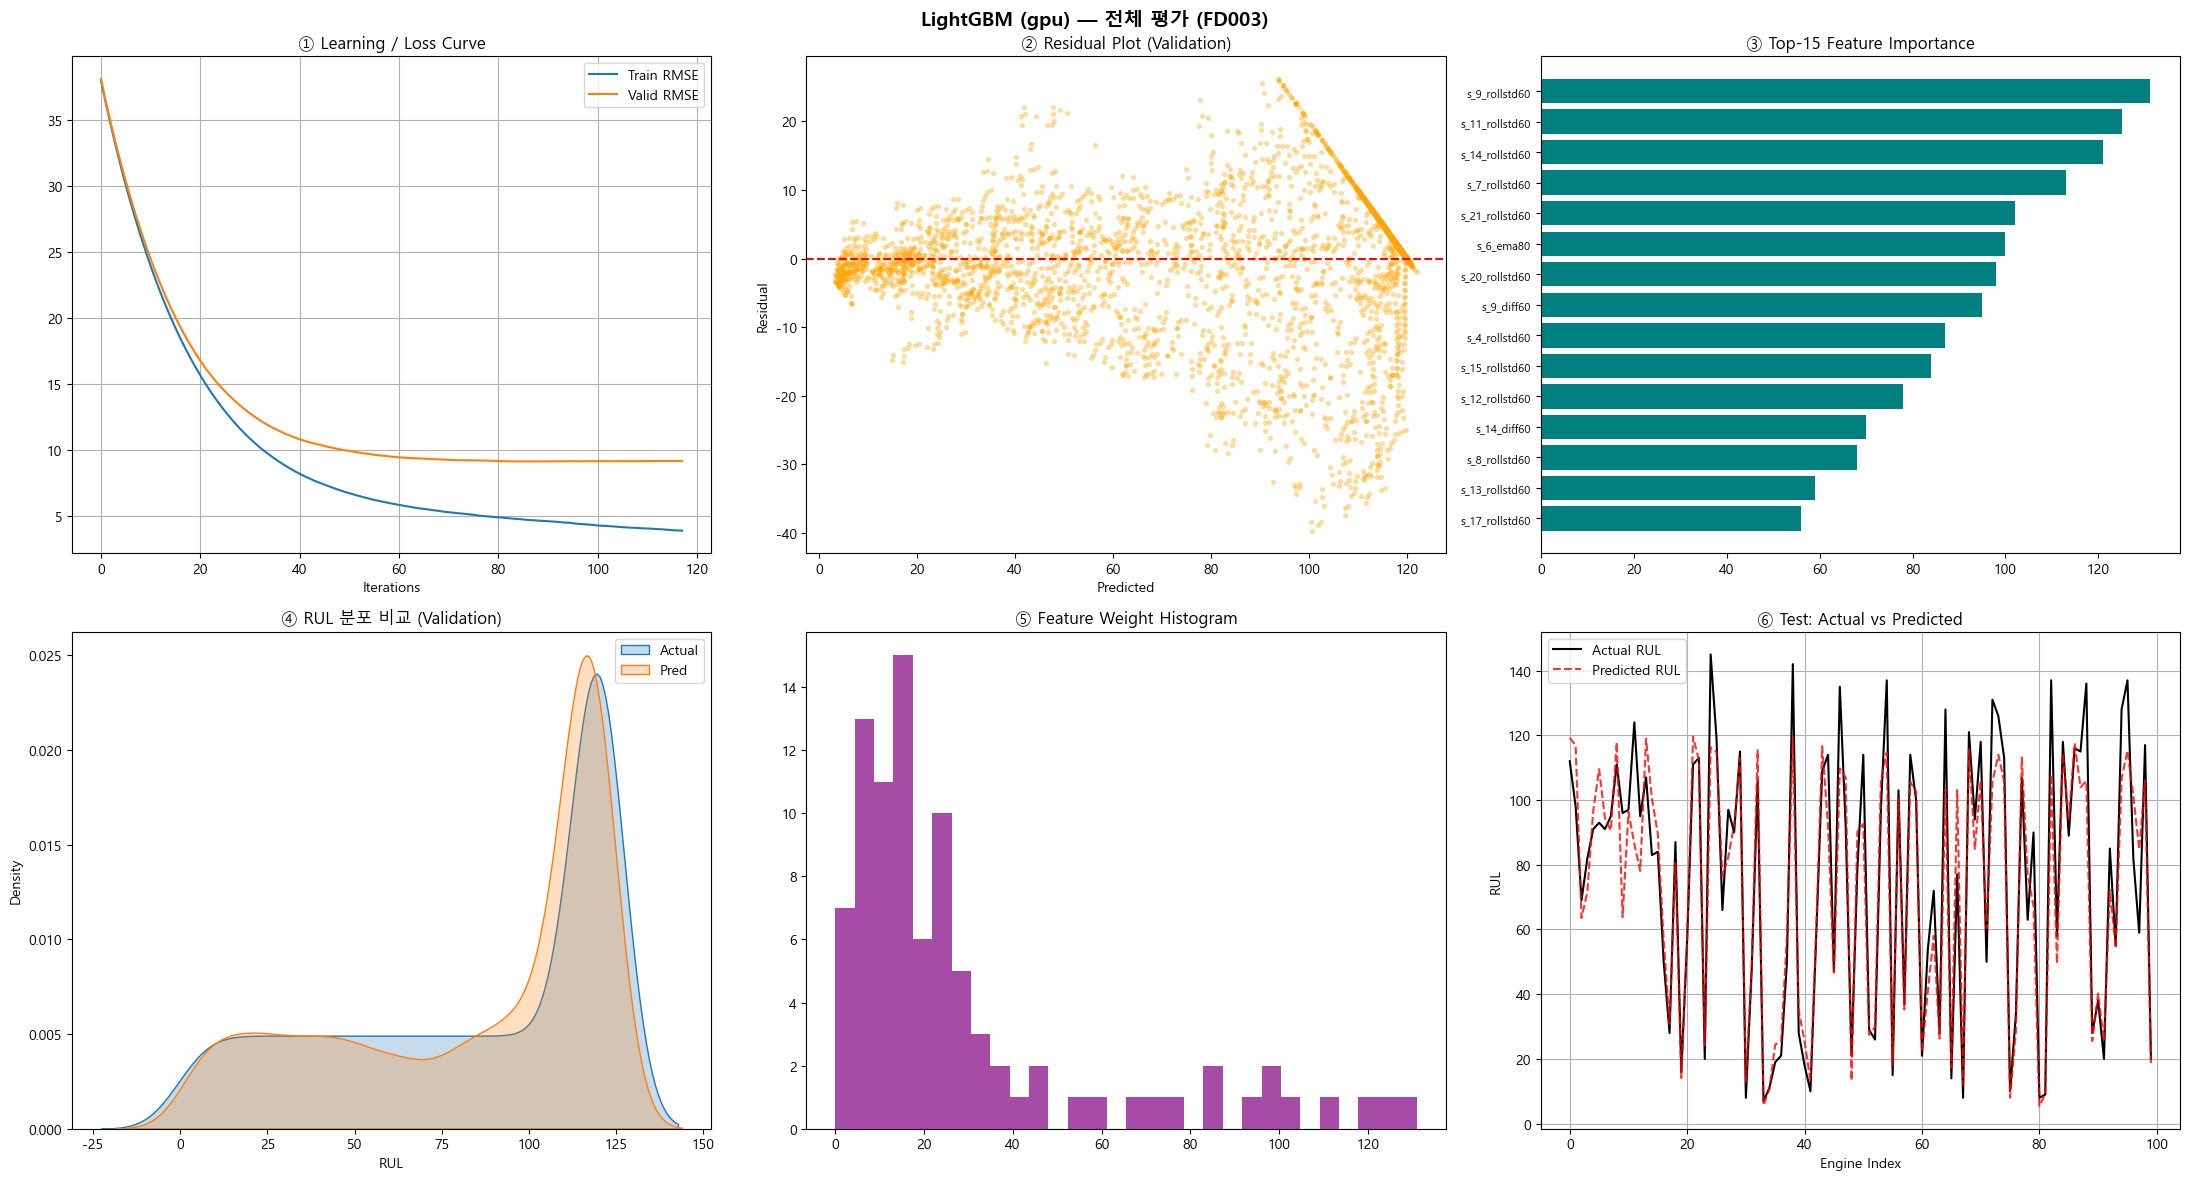

{'Train': {'RMSE': 4.650074383900554,
  'MAE': 3.131747159466464,
  'R2': 0.9863781361337796,
  'NASA_Score': 7045.504582024005},
 'Valid': {'RMSE': 9.105409135579917,
  'MAE': 6.03162113726866,
  'R2': 0.9479607795241313,
  'NASA_Score': 5920.166798988514},
 'Test': {'RMSE': 13.071148137356381,
  'MAE': 9.745535513433516,
  'R2': 0.9010609060297806,
  'NASA_Score': 211.33603972427727}}

In [13]:
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
res_lgb  = model_lgb.evals_result_
eval_dict_lgb = {'train': res_lgb['training']['rmse'],
                 'valid': res_lgb['valid_1']['rmse']}
evaluate_full_pipeline(model_lgb, f'LightGBM ({LGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_lgb)



 🏆 XGBoost (cuda) 평가 결과
 [Train] RMSE=0.9652 | MAE=0.6358 | R2=0.9994 | NASA=984.5
 [Valid] RMSE=8.8887 | MAE=5.7246 | R2=0.9504 | NASA=6097.7
 [Test ] RMSE=13.3909 | MAE=10.0619 | R2=0.8962 | NASA=224.0


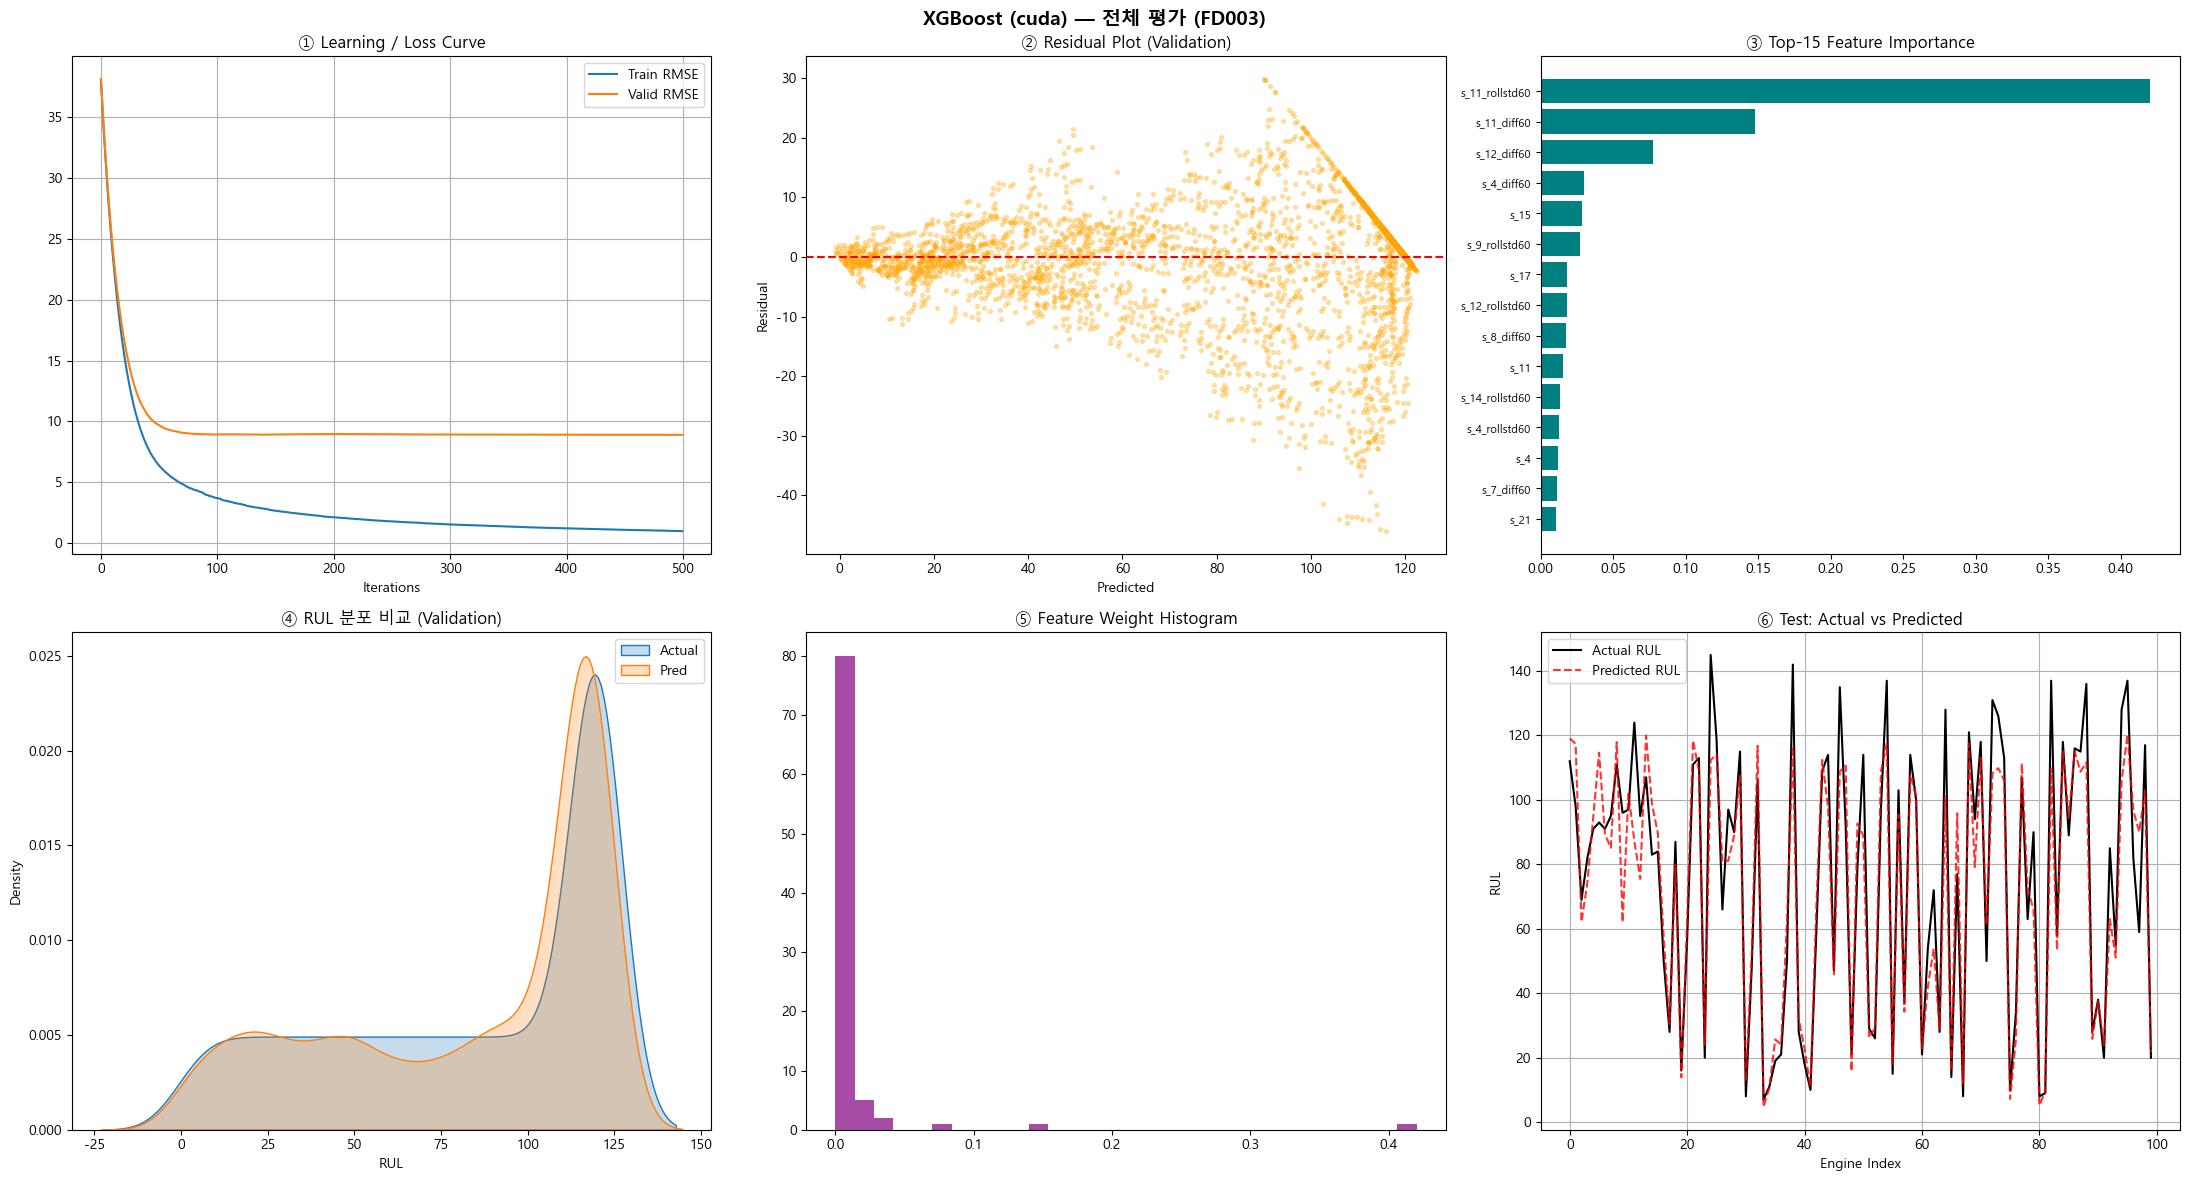

{'Train': {'RMSE': 0.9651652846541461,
  'MAE': 0.6357812024020867,
  'R2': 0.9994131594424781,
  'NASA_Score': 984.5408339022558},
 'Valid': {'RMSE': 8.888686694137824,
  'MAE': 5.724563357753894,
  'R2': 0.9504085222368657,
  'NASA_Score': 6097.674761579185},
 'Test': {'RMSE': 13.390890138154788,
  'MAE': 10.061890296936035,
  'R2': 0.8961612743127036,
  'NASA_Score': 224.02426653168186}}

In [14]:
# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, f'XGBoost ({XGB_DEVICE})', is_tree=True, is_boosting=True, eval_results=eval_dict_xgb)


## 7. Optuna 튜닝 설정

In [14]:
# ============================================================
# ⚙️ OPTUNA 설정
# ============================================================
N_TRIALS_LIN    = 30      # 선형 모델
N_TRIALS_TREE   = 50      # 트리 모델
OPTUNA_METRIC   = 'rmse'  # 'rmse' | 'nasa'
N_SPLITS        = 5       # GroupKFold
INNER_VAL_RATIO = 0.15    # ES용 inner-val 비율

groups = train_ml['unit_nr'].values
gkf    = GroupKFold(n_splits=N_SPLITS)

ALL_RESULTS = {}
BEST_MODELS = {}

# ── 헬퍼 ──────────────────────────────────────────────────────────────────
def clip_rul(pred, cap=CONFIG['rul_cap']):
    return np.clip(pred, 0, cap)

def cv_score(builder, X, y, grp, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        m = builder()
        m.fit(X.iloc[ti], y.iloc[ti])
        pred = clip_rul(m.predict(X.iloc[vi]))
        rmse_list.append(float(np.sqrt(mean_squared_error(y.iloc[vi], pred))))
        nasa_list.append(float(calculate_nasa_score(y.iloc[vi], pred) / max(len(y.iloc[vi]), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)), 'cv_nasa_mean': float(np.mean(nasa_list))}

def _inner_split(X, y, grp, val_ratio=INNER_VAL_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    units = np.array(sorted(set(grp)))
    rng.shuffle(units)
    n_va  = max(1, int(len(units) * val_ratio))
    va_set = set(units[:n_va])
    mask   = np.array([g in va_set for g in grp])
    return X[~mask], y[~mask], X[mask], y[mask]

def _fit_with_es(model, name, Xtr, ytr, Xva=None, yva=None):
    if name == 'RandomForest' or Xva is None:
        model.fit(Xtr, ytr)
    elif name == 'XGBoost':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    elif name == 'LightGBM':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

def cv_score_es(builder, X, y, grp, name, metric=OPTUNA_METRIC):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr_f = X.iloc[ti]; ytr_f = y.iloc[ti]
        Xva   = X.iloc[vi]; yva   = y.iloc[vi]
        model = builder()
        if name in ('XGBoost', 'LightGBM'):
            X_in, y_in, X_iv, y_iv = _inner_split(
                Xtr_f.values, ytr_f.values, grp[ti])
            X_in = pd.DataFrame(X_in, columns=X.columns)
            X_iv = pd.DataFrame(X_iv, columns=X.columns)
            _fit_with_es(model, name, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))
        else:
            _fit_with_es(model, name, Xtr_f, ytr_f)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(float(np.sqrt(mean_squared_error(yva, pred))))
        nasa_list.append(float(calculate_nasa_score(yva, pred) / max(len(yva), 1)))
    return {'cv_rmse_mean': float(np.mean(rmse_list)),
            'cv_rmse_std' : float(np.std(rmse_list)),
            'cv_nasa_mean': float(np.mean(nasa_list))}

print('✅ Optuna 설정 완료')
print(f'   N_TRIALS: 선형={N_TRIALS_LIN} / 트리={N_TRIALS_TREE}')
print(f'   Metric  : {OPTUNA_METRIC.upper()} | CV splits: {N_SPLITS}')


✅ Optuna 설정 완료
   N_TRIALS: 선형=30 / 트리=50
   Metric  : RMSE | CV splits: 5


## 8. Optuna — 선형 모델 (Ridge / Lasso / ElasticNet)

In [15]:
def _build_linear(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True),
                     solver=trial.suggest_categorical('solver', ['auto','svd','cholesky','lsqr']),
                     max_iter=3000, random_state=RANDOM_STATE)
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                     selection=trial.suggest_categorical('selection', ['cyclic','random']),
                     max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    elif name == 'ElasticNet':
        return ElasticNet(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
                          l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
                          selection=trial.suggest_categorical('selection', ['cyclic','random']),
                          max_iter=3000, tol=0.001, random_state=RANDOM_STATE)
    raise ValueError(name)

for mname in ['Ridge', 'Lasso', 'ElasticNet']:
    t0 = time.time()
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_LIN} trials)', end='', flush=True)

    def _obj_lin(trial, _m=mname):
        res = cv_score(lambda: _build_linear(trial, _m), X_train, y_train, groups)
        return res['cv_nasa_mean'] if OPTUNA_METRIC == 'nasa' else res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(_obj_lin, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_linear(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train, y_train)

    cv_res    = cv_score(lambda: _build_linear(optuna.trial.FixedTrial(best_p), mname),
                         X_train, y_train, groups)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'linear', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ 선형 모델 최적화 완료')


[Ridge] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.270 | Val RMSE=11.618 | Test NASA=399.4 | 7s
   best_params: {'alpha': 3.2739793146694587, 'solver': 'lsqr'}
[Lasso] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.312 | Val RMSE=11.652 | Test NASA=404.2 | 3270s
   best_params: {'alpha': 0.004103080115354905, 'selection': 'random'}
[ElasticNet] 최적화 시작 ... (30 trials)  ✅ | CV RMSE=13.270 | Val RMSE=11.631 | Test NASA=400.4 | 2090s
   best_params: {'alpha': 0.000431443787682104, 'l1_ratio': 0.4647697418887721, 'selection': 'random'}

✅ 선형 모델 최적화 완료


## 9. Optuna — RandomForest (CPU)

In [16]:
def _build_rf(trial):
    return RandomForestRegressor(
        n_estimators      = trial.suggest_int  ('n_estimators',    100, 600),
        max_depth         = trial.suggest_int  ('max_depth',         5,  30),
        min_samples_split = trial.suggest_int  ('min_samples_split', 2,  20),
        min_samples_leaf  = trial.suggest_int  ('min_samples_leaf',  1,  10),
        max_features      = trial.suggest_float('max_features',     0.2, 1.0),
        random_state=RANDOM_STATE, n_jobs=-1)

t0 = time.time()
print(f'[RandomForest] 최적화 시작 ... ({N_TRIALS_TREE} trials)')

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_rf.optimize(
    lambda t: cv_score_es(lambda: _build_rf(t), X_train, y_train, groups, 'RandomForest')
             ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
    n_trials=N_TRIALS_TREE, show_progress_bar=False)

best_p = study_rf.best_params
best_m = _build_rf(optuna.trial.FixedTrial(best_p))
best_m.fit(X_train, y_train)

cv_res    = cv_score_es(lambda: _build_rf(optuna.trial.FixedTrial(best_p)),
                         X_train, y_train, groups, 'RandomForest')
val_mets  = get_metrics(y_val,  best_m.predict(X_val))
test_mets = get_metrics(y_test, best_m.predict(X_test))

ALL_RESULTS['RandomForest'] = {
    'type':'tree', 'model':best_m, 'params':best_p,
    'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
    'cv_nasa':cv_res['cv_nasa_mean'],
    'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
}
BEST_MODELS['RandomForest'] = best_m

print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_mets["RMSE"]:.3f} '
      f'| Test NASA={test_mets["NASA_Score"]:.1f} | {time.time()-t0:.0f}s')
print(f'   best_params: {best_p}')


[RandomForest] 최적화 시작 ... (50 trials)
  ✅ | CV RMSE=8.781 | Val RMSE=8.760 | Test NASA=222.6 | 1032s
   best_params: {'n_estimators': 353, 'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 0.3495422326508779}


## 10. Optuna — XGBoost / LightGBM (GPU 자동)

In [17]:
def _build_boost(trial, name):
    if name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators          = trial.suggest_int  ('n_estimators',     150, 700),
            max_depth             = trial.suggest_int  ('max_depth',          3,  10),
            learning_rate         = trial.suggest_float('learning_rate',   0.01, 0.3,  log=True),
            subsample             = trial.suggest_float('subsample',        0.5, 1.0),
            colsample_bytree      = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha             = trial.suggest_float('reg_alpha',       1e-8,  10,  log=True),
            reg_lambda            = trial.suggest_float('reg_lambda',      1e-8,  10,  log=True),
            early_stopping_rounds = 30,
            tree_method='hist', device=XGB_DEVICE,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators     = trial.suggest_int  ('n_estimators',    150, 700),
            max_depth        = trial.suggest_int  ('max_depth',         3,  12),
            learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3,  log=True),
            num_leaves       = trial.suggest_int  ('num_leaves',       15, 255),
            subsample        = trial.suggest_float('subsample',       0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
            reg_alpha        = trial.suggest_float('reg_alpha',      1e-8,  10,  log=True),
            reg_lambda       = trial.suggest_float('reg_lambda',     1e-8,  10,  log=True),
            device=LGB_DEVICE, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    raise ValueError(name)

for mname in ['XGBoost', 'LightGBM']:
    t0  = time.time()
    dev = XGB_DEVICE if mname == 'XGBoost' else LGB_DEVICE
    print(f'[{mname}] 최적화 시작 ... ({N_TRIALS_TREE} trials) | device={dev}')

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(
        lambda t, _m=mname: cv_score_es(lambda: _build_boost(t, _m), X_train, y_train, groups, _m)
                            ['cv_nasa_mean' if OPTUNA_METRIC=='nasa' else 'cv_rmse_mean'],
        n_trials=N_TRIALS_TREE, show_progress_bar=False)

    best_p = study.best_params
    best_m = _build_boost(optuna.trial.FixedTrial(best_p), mname)

    X_in, y_in, X_iv, y_iv = _inner_split(X_train.values, y_train.values, groups)
    X_in = pd.DataFrame(X_in, columns=ML_FEATURES)
    X_iv = pd.DataFrame(X_iv, columns=ML_FEATURES)
    _fit_with_es(best_m, mname, X_in, pd.Series(y_in), X_iv, pd.Series(y_iv))

    cv_res    = cv_score_es(lambda: _build_boost(optuna.trial.FixedTrial(best_p), mname),
                             X_train, y_train, groups, mname)
    val_mets  = get_metrics(y_val,  best_m.predict(X_val))
    test_mets = get_metrics(y_test, best_m.predict(X_test))

    ALL_RESULTS[mname] = {
        'type':'tree', 'model':best_m, 'params':best_p,
        'cv_rmse':cv_res['cv_rmse_mean'], 'cv_rmse_std':cv_res['cv_rmse_std'],
        'cv_nasa':cv_res['cv_nasa_mean'],
        'val_metrics':val_mets, 'test_metrics':test_mets, 'fit_seconds':time.time()-t0
    }
    BEST_MODELS[mname] = best_m

    print(f'  ✅ | CV RMSE={cv_res["cv_rmse_mean"]:.3f}±{cv_res["cv_rmse_std"]:.3f} '
          f'| Val RMSE={val_mets["RMSE"]:.3f} '
          f'| Test NASA={test_mets["NASA_Score"]:.1f} '
          f'| {time.time()-t0:.0f}s')
    print(f'   best_params: {best_p}')

print('\n✅ Boosting 모델 최적화 완료')


[XGBoost] 최적화 시작 ... (50 trials) | device=cuda
  ✅ | CV RMSE=9.036±0.523 | Val RMSE=8.952 | Test NASA=218.6 | 197s
   best_params: {'n_estimators': 636, 'max_depth': 4, 'learning_rate': 0.04374638435986673, 'subsample': 0.9362705527423543, 'colsample_bytree': 0.5009770948275385, 'reg_alpha': 0.00043209775769999036, 'reg_lambda': 4.647332015356221e-06}
[LightGBM] 최적화 시작 ... (50 trials) | device=gpu
  ✅ | CV RMSE=9.021±0.546 | Val RMSE=8.617 | Test NASA=221.2 | 748s
   best_params: {'n_estimators': 371, 'max_depth': 12, 'learning_rate': 0.018401332131057133, 'num_leaves': 32, 'subsample': 0.7601714864271332, 'colsample_bytree': 0.5150108633165521, 'reg_alpha': 0.07243371594611293, 'reg_lambda': 0.00016901356798553434}

✅ Boosting 모델 최적화 완료


## 11. 전체 모델 비교표

In [18]:
rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        'Model'    : mname,
        'CV_RMSE'  : round(res['cv_rmse'], 4),
        'Val_RMSE' : round(res['val_metrics']['RMSE'], 4),
        'Val_NASA' : round(res['val_metrics']['NASA_Score'], 1),
        'Test_RMSE': round(res['test_metrics']['RMSE'], 4),
        'Test_NASA': round(res['test_metrics']['NASA_Score'], 1),
        'Test_R2'  : round(res['test_metrics']['R2'], 4),
        'Time(s)'  : round(res['fit_seconds'], 1),
    })

summary_df = pd.DataFrame(rows).sort_values('Test_RMSE').reset_index(drop=True)
print('\n' + '='*70)
print('📊 모델 성능 비교표 — FD003 (Test RMSE 기준 정렬)')
print('='*70)
print(summary_df.to_string(index=False))
print('='*70)

best_name = summary_df.iloc[0]['Model']
print(f'\n🏆 최고 성능 모델: {best_name}')
print(f'   Test RMSE  = {summary_df.iloc[0]["Test_RMSE"]}')
print(f'   Test NASA  = {summary_df.iloc[0]["Test_NASA"]}')
print(f'   Test R²    = {summary_df.iloc[0]["Test_R2"]}')



📊 모델 성능 비교표 — FD003 (Test RMSE 기준 정렬)
       Model  CV_RMSE  Val_RMSE  Val_NASA  Test_RMSE  Test_NASA  Test_R2  Time(s)
     XGBoost   9.0359    8.9521    5750.1    13.0168      218.6   0.9019    196.9
RandomForest   8.7812    8.7595    5537.0    13.1471      222.6   0.8999   1031.8
    LightGBM   9.0207    8.6167    5526.9    13.1698      221.2   0.8996    747.6
       Lasso  13.3119   11.6518    7943.0    16.8132      404.2   0.8363   3269.8
       Ridge  13.2704   11.6178    7844.6    16.8269      399.4   0.8360      6.9
  ElasticNet  13.2699   11.6306    7865.4    16.8470      400.4   0.8356   2089.9

🏆 최고 성능 모델: XGBoost
   Test RMSE  = 13.0168
   Test NASA  = 218.6
   Test R²    = 0.9019


## 12. Optuna 최적 파라미터로 재시각화 (원하는 모델 선택)

🎯 [XGBoost] 최적 파라미터 시각화
   Params: {'n_estimators': 636, 'max_depth': 4, 'learning_rate': 0.04374638435986673, 'subsample': 0.9362705527423543, 'colsample_bytree': 0.5009770948275385, 'reg_alpha': 0.00043209775769999036, 'reg_lambda': 4.647332015356221e-06}

 🏆 XGBoost (Optuna 최적) 평가 결과
 [Train] RMSE=5.9832 | MAE=3.9358 | R2=0.9774 | NASA=10382.8
 [Valid] RMSE=9.0394 | MAE=6.0687 | R2=0.9487 | NASA=5840.7
 [Test ] RMSE=13.2078 | MAE=10.2965 | R2=0.8990 | NASA=219.5


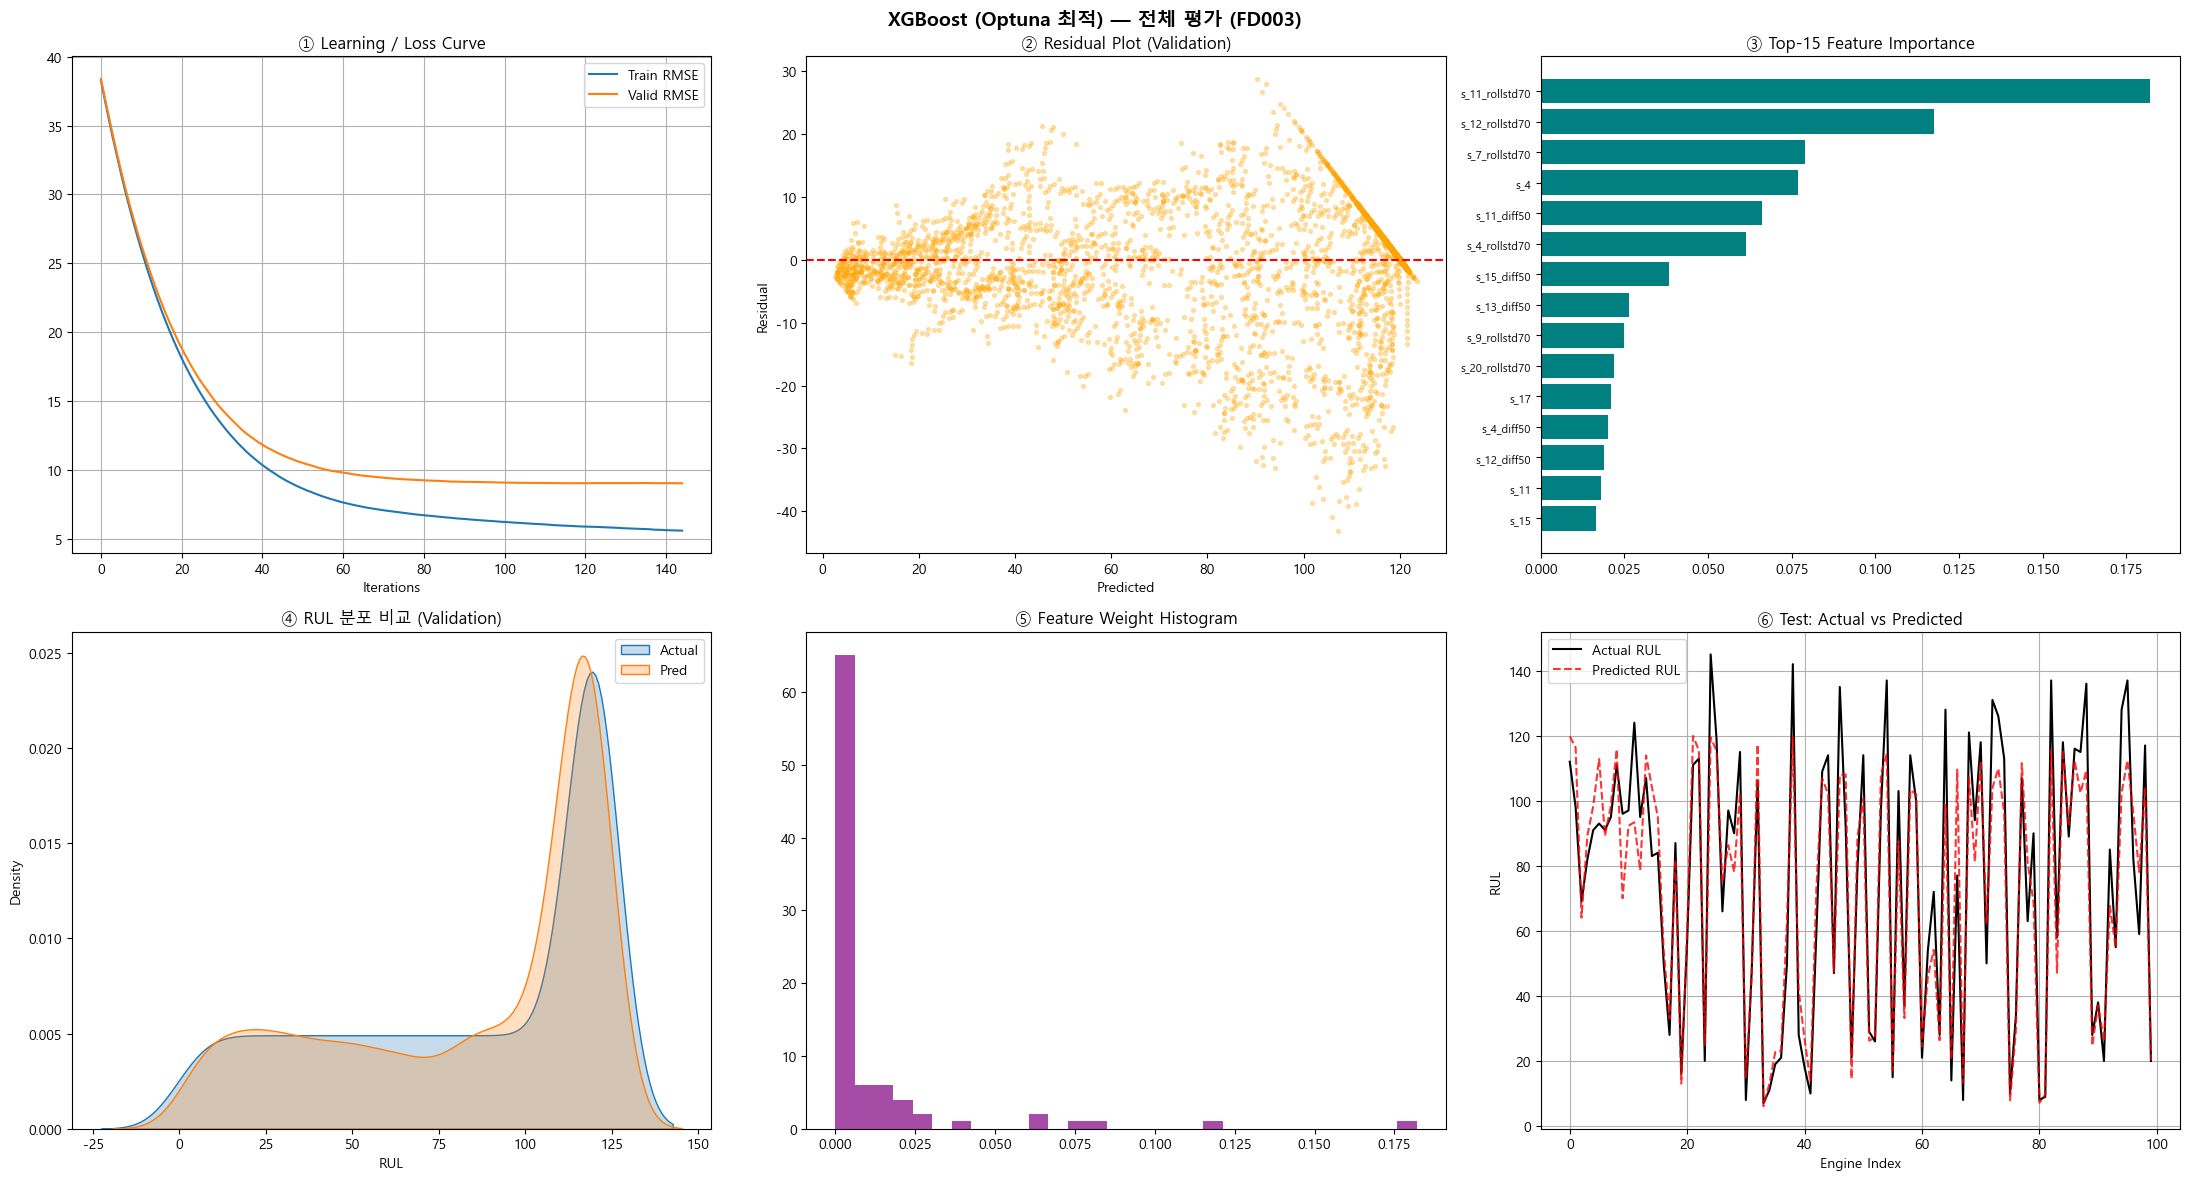

{'Train': {'RMSE': 5.983171550964252,
  'MAE': 3.9358432418042844,
  'R2': 0.9774482812803694,
  'NASA_Score': 10382.8323772261},
 'Valid': {'RMSE': 9.0393947432948,
  'MAE': 6.068697915791879,
  'R2': 0.9487126149072617,
  'NASA_Score': 5840.667833795527},
 'Test': {'RMSE': 13.207842084607735,
  'MAE': 10.296480178833008,
  'R2': 0.8989807380175462,
  'NASA_Score': 219.5272880489139}}

In [19]:
# ── 재평가할 모델 이름 지정 ────────────────────────────────────────────────
TARGET_MODEL = best_name   # 또는 'XGBoost', 'LightGBM', 'Ridge' 등 직접 지정

best_model = BEST_MODELS[TARGET_MODEL]
res_info   = ALL_RESULTS[TARGET_MODEL]
is_tree    = res_info['type'] == 'tree'
is_boost   = TARGET_MODEL in ('XGBoost', 'LightGBM')

print(f'🎯 [{TARGET_MODEL}] 최적 파라미터 시각화')
print(f'   Params: {res_info["params"]}')

# XGBoost / LightGBM: eval_results 재구성
eval_results_refit = None
if is_boost:
    if TARGET_MODEL == 'XGBoost':
        best_model.fit(X_train, y_train,
                       eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
        r2 = best_model.evals_result()
        eval_results_refit = {'train':r2['validation_0']['rmse'], 'valid':r2['validation_1']['rmse']}
    elif TARGET_MODEL == 'LightGBM':
        best_model.fit(X_train, y_train,
                       eval_set=[(X_train, y_train),(X_val, y_val)],
                       callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
        r2 = best_model.evals_result_
        eval_results_refit = {'train':r2['training']['rmse'], 'valid':r2['valid_1']['rmse']}

evaluate_full_pipeline(best_model, f'{TARGET_MODEL} (Optuna 최적)',
                       is_tree=is_tree, is_boosting=is_boost, eval_results=eval_results_refit)


# 누수 확인

In [ ]:
# 체크 1: scaler 누수
# scaler_obj와 X_train을 사용한 누수 체크
fit_size = scaler_obj.n_samples_seen_
actual_train_size = len(X_train)

print(f"📊 Scaler Fit Size (스케일러가 본 샘플 수): {fit_size}")
print(f"📊 X_train Size (실제 훈련 데이터 샘플 수): {actual_train_size}")

if fit_size == actual_train_size:
    print("✅ 정합성 확인: 데이터 누수 없음! 오직 훈련 데이터로만 스케일링 기준을 잡았습니다.")
else:
    print("⚠️ 경고: 데이터 누수 가능성! 숫자가 일치하지 않습니다. 스케일러 fit 과정을 점검하세요.")
# 같으면 ok 더 커면 누수

In [ ]:
## 체크 2 & 3
# 실제 존재하는 센서 컬럼 하나를 자동으로 선택
existing_sensors = [col for col in test_ml.columns if 's_' in col and 'lag' not in col and 'roll' not in col]
target_s = existing_sensors[0] if existing_sensors else 'sensor_column_name'

# 해당 센서의 lag와 roll 컬럼 찾기
lag_col = [col for col in test_ml.columns if f'{target_s}_lag' in col][0]
roll_col = [col for col in test_ml.columns if f'{target_s}_roll' in col][0]

u = test_ml[test_ml['unit_nr'] == 1]

print(f"--- {target_s} 기반 시계열 체크 ---")
display(u[['time_cycles', target_s, lag_col]].head(10)) # 체크 2
display(u[[target_s, roll_col]].tail())                # 체크 3

In [ ]:
# lag/rolling이 미래 참조 없음
# 체크 2: test 미래 참조
# 특정 유닛 하나 확인
u = test_ml[test_ml['unit_nr'] == 1]

print("--- [검증 완료] s_2 기반 시계열 체크 ---")
# 1. Lag 확인 (초반 45행: lag40이므로 40행까지는 0이어야 함)
print("1. Lag Check (Head):")
print(u[['time_cycles', 's_2', 's_2_lag40']].head(45))

# 2. Rolling 확인 (마지막 5행: 이전 데이터의 평균이 계산되어야 함)
# 만약 roll40이 아닌 다른 이름(roll50 등)이라면 그에 맞춰 수정하세요.
roll_col = [col for col in u.columns if 's_2_roll' in col][0]
print(f"\n2. Rolling Check (Tail) - {roll_col}:")
print(u[['s_2', roll_col]].tail())
# 갑자기 미래 값 반영되면 이상

In [ ]:
# s_2가 포함된 모든 컬럼명 출력
print([col for col in train_ml.columns if 's_2' in col])

In [ ]:
# 체크 4: gaussian 누수 (여기 중요)
# 초반부터 너무 부드러우면 미래 참조 가능성 높음

# 1. unit_nr이 어디에 있는지 확인
if 'unit_nr' in train_ml.columns:
    sample = train_ml[train_ml['unit_nr'] == train_ml['unit_nr'].unique()[0]].copy()
    print(f"✅ 'unit_nr' 컬럼에서 데이터를 찾았습니다. (Unit ID: {train_ml['unit_nr'].unique()[0]})")
elif train_ml.index.name == 'unit_nr' or 'unit_nr' in train_ml.index.names:
    # 인덱스에 들어있는 경우
    first_unit = train_ml.index.get_level_values('unit_nr')[0]
    sample = train_ml.xs(first_unit, level='unit_nr').copy()
    print(f"✅ 인덱스에서 'unit_nr'을 찾았습니다. (Unit ID: {first_unit})")
else:
    # 둘 다 아니면 그냥 맨 위 100개 데이터 사용
    sample = train_ml.head(100).copy()
    print("⚠️ 'unit_nr'을 찾을 수 없어 상위 100개 행을 추출합니다.")

# 2. 시각화 실행
raw_col = 's_2'
smooth_col = 's_2_ema40'

plt.figure(figsize=(12, 5))

# iloc를 사용해 데이터 유무와 상관없이 강제 플로팅
plt.plot(sample[raw_col].values[:150], label='Raw (s_2)', color='lightgray', marker='o', markersize=3, alpha=0.8)
plt.plot(sample[smooth_col].values[:150], label='Smoothed (EMA40)', color='red', linewidth=2)

plt.title("Final Leakage Check: Time Series Flow")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 데이터 샘플 출력 (직접 눈으로 확인)
print("\n--- [데이터 샘플 직접 확인] ---")
print(sample[[raw_col, smooth_col]].head(10))

In [ ]:
# 체크 5: test evaluation
print(len(test_last), len(rul_df))
# 같아야 정상

In [ ]:
# 체크 6: feature 생성 순서 (가장 많이 틀림)
# 현재 메모리에 있는 실제 데이터 변수명으로 매칭
# 피처 생성 전: train_raw (또는 전처리 전 단계의 df)
# 피처 생성 후: train_ml

try:
    print("--- [검증] Feature 생성 전/후 크기 비교 ---")
    print("Before (Original):", train_raw.shape)
    print("After  (Engineered):", train_ml.shape)
    
    new_features = train_ml.shape[1] - train_raw.shape[1]
    print(f"추가된 피처 수: {new_features}개")

    if new_features > 0:
        print("✅ 정합성 확인: 시계열 파생 변수가 정상적으로 생성되었습니다.")
    else:
        print("⚠️ 경고: 추가된 피처가 없습니다. 함수 적용 여부를 확인하세요.")

except NameError:
    # 만약 train_raw가 없다면 X_train 등을 활용
    print("변수명을 찾을 수 없습니다. [train_raw, train_ml] 변수가 있는지 확인해 주세요.")